# k-means-clustering example #

In [45]:
import numpy as np
import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## reading the .csv file ##

In [46]:
# reading the dataset csv file
path_to_data_set    =    "/home/jwalitnpanchal/college_work/sem10/ML_AI/k_means_clustering/city_lifestyle_dataset.csv"
data_set    =    pd.read_csv(path_to_data_set)
print(data_set.columns,"\n", data_set)

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio'],
      dtype='object') 
          city_name  country  population_density  avg_income  \
0        Old Vista   Europe                2775        3850   
1        Beachport   Europe                3861        3700   
2    Valleyborough   Europe                2562        4310   
3             City   Europe                3192        3970   
4            Falls   Europe                3496        4320   
..             ...      ...                 ...         ...   
295     Old Harbor  Oceania                1004        4620   
296     Ridgehaven  Oceania                1652        4500   
297    North Field  Oceania                 836        3910   
298     Bridgeford  Oceania                 758        3490   
299      Townshire  Oceania                1235        4330   

     internet_

## trial at KMeans using sklearn ##
the data is clustered in to five

In [47]:
# select two coloums of interest from the above dataframe
c1    =     "avg_income"
c2    =     "internet_penetration"
two_coloums    =    data_set[[c1,c2]]
#print(two_coloums)
# scaling the data to standard
std_scale    =    StandardScaler()
std_two_coloums    =    std_scale.fit_transform(two_coloums)
#print(std_two_coloums)

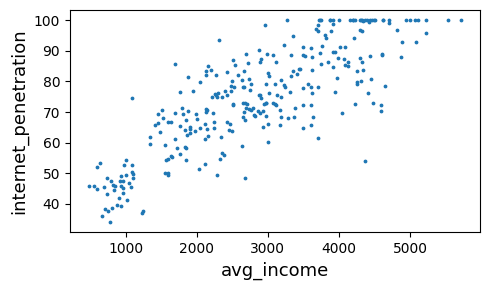

In [48]:
# plotting the scatter plot of the above two coloums to see if any clusters are possible
figsize=(5,3)
plt.figure(1, figsize=figsize)
plt.scatter(two_coloums[c1], two_coloums[c2],s=3)
plt.xlabel(c1, fontsize=13)
plt.ylabel(c2, fontsize=13)
plt.tight_layout()
plt.show()

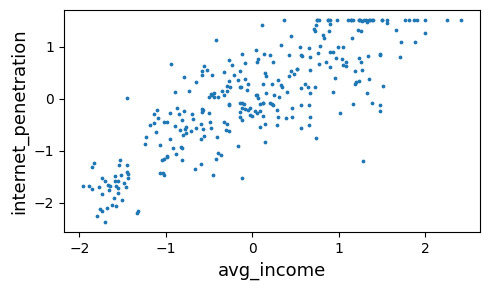

In [49]:
# plotting the scatter plot of the above standardized two coloums to see if any clusters are possible
figsize=(5,3)
plt.figure(1, figsize=figsize)
plt.scatter(std_two_coloums[:,0], std_two_coloums[:,1],s=3)
plt.xlabel(c1, fontsize=13)
plt.ylabel(c2, fontsize=13)
plt.tight_layout()
plt.show()

In [50]:
# just example checking how to use KMeans class to cluster the data and plot the various cluster centroids
cluster_no = 5
cluster    =  KMeans(n_clusters=cluster_no, random_state=42, max_iter=300)  
clustered_data    =    cluster.fit(std_two_coloums)
clustered_data_labels    =    clustered_data.labels_
clustered_data_centers   =    clustered_data.cluster_centers_
print(clustered_data.labels_, "\n", clustered_data.cluster_centers_)

[2 4 4 4 2 4 4 4 2 2 4 4 4 0 4 4 0 0 0 0 0 2 2 3 2 0 2 0 4 2 4 0 2 0 2 2 0
 0 0 2 4 0 2 4 0 0 2 4 2 2 0 4 4 0 4 2 3 2 0 2 0 3 3 0 4 0 0 0 0 4 1 0 0 3
 0 0 0 2 1 0 0 3 0 0 3 3 3 0 0 0 3 0 0 0 0 0 4 3 2 3 0 3 3 0 3 3 0 0 3 3 3
 0 0 0 3 0 0 3 3 0 0 0 0 3 0 3 4 3 0 0 0 0 0 4 0 0 0 0 3 0 2 2 2 4 4 3 2 2
 2 0 4 4 2 2 2 2 2 2 2 4 4 4 0 2 4 2 2 2 2 0 2 2 2 0 2 4 2 2 2 4 2 4 2 2 0
 2 2 2 2 4 3 1 3 3 3 3 3 3 3 3 3 1 3 3 3 0 0 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3
 3 3 3 3 3 3 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 4 2 2 2 2 2 2 2 2 0 0 0 4 4 2 2 4 2 2 4 2 2 4 2 0 2 4 0 4 2
 2 2 2 2] 
 [[-0.14744933  0.18837713]
 [-1.5798697  -1.69854504]
 [ 1.14919008  1.22785661]
 [-0.73793712 -0.67174006]
 [ 0.77162326  0.05922664]]


In [51]:
# appending a coloumn to the std_two_coloums called cluster_number that indicates which cluster the data belongs to
two_coloums["cluster_number"]    =    clustered_data.labels_
#print(two_coloums)

/tmp/ipykernel_238611/1735756856.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_coloums["cluster_number"]    =    clustered_data.labels_


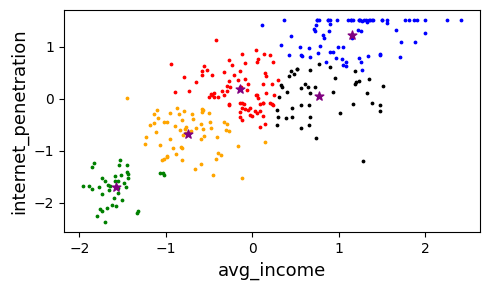

In [52]:
# plotting the scatter plot of the above standardized two coloums to see if any clusters are possible with the cluster centers
color    =    ["red", "green", "blue", "orange", "black"]
unique_labels    =    np.unique(clustered_data.labels_)
figsize=(5,3)
plt.figure(1, figsize=figsize)
#[plt.scatter(two_coloums[:,0,j], std_two_coloums[:,1,j],s=3,color=color[j]) for j in range(cluster_no)]
for label in unique_labels:
    unique_std_clustered_data    =    std_two_coloums[clustered_data_labels==label]
    plt.scatter(unique_std_clustered_data[:,0], unique_std_clustered_data[:,1],s=3, color=color[label])
plt.scatter(clustered_data_centers[:,0], clustered_data_centers[:,1],s=42, color="purple",marker="*")
plt.xlabel(c1, fontsize=13)
plt.ylabel(c2, fontsize=13)
plt.tight_layout()
plt.show()

## trial at making the elbow plot ##

In [64]:
# we can first try the elbow plot to see how many clusters should be made
inertia_list    =    []
cluster_number  =    []
for i in range(1,16):
    # instantiate the cluster class
    cluster    =    KMeans(n_clusters=i, random_state=42)
    # use the fit method of the class KMeans to categorize the data points into clusters
    cluster.fit(std_two_coloums)
    print(i,cluster.inertia_)
    inertia_list.append(cluster.inertia_)
    cluster_number.append(i)

1 600.0000000000001
2 238.03778998344214
3 125.48461470620731
4 91.13208433716471
5 72.87000224571146
6 61.90847536715357
7 51.033391235642235
8 46.22196325663826
9 40.84680881596016
10 35.48642104137703
11 32.406247605503005
12 29.26221586165959
13 27.282029725770812
14 24.879361676060427
15 23.86341232266971


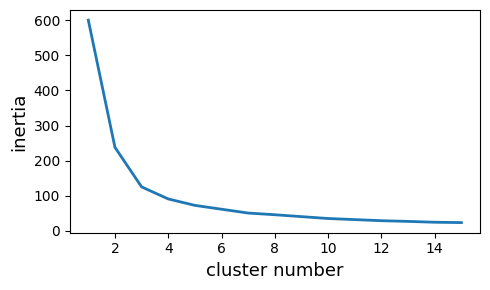

In [65]:
# plotting the elbow graph by plotting on x-axis the cluster number and on the y-axis the inertia (wcss) score
plt.figure(2, figsize=figsize)
plt.plot(cluster_number, inertia_list, lw=2)
plt.xlabel(r"cluster number", fontsize=13)
plt.ylabel(r"inertia", fontsize=13)
plt.tight_layout()
plt.show()

## silhouette score plot ##
checking the silhouette score for the quality of clustering

In [76]:
# trial at making silhouette plot
sil_score    =    []
for i in range(2,16):
    # instantiate the cluster class
    cluster    =    KMeans(n_clusters=i, random_state=42)
    # use the fit method of the class KMeans to categorize the data points into clusters
    cluster.fit(std_two_coloums)
    sil_score.append(silhouette_score(std_two_coloums, cluster.labels_))
    print(i,silhouette_score(std_two_coloums, cluster.labels_))

2 0.4919751677985056
3 0.47726410494823795
4 0.4488070192420949
5 0.41775276682066365
6 0.3993405791100945
7 0.4162939471941143
8 0.3769106833426961
9 0.3994672470659968
10 0.3955935926837942
11 0.40128478681587826
12 0.40043048701808887
13 0.3909511080564842
14 0.3835389997976673
15 0.3760094786421006


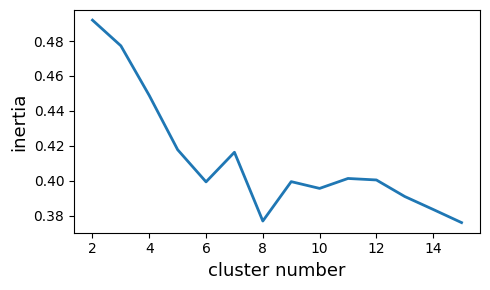

In [69]:
# plotting the elbow graph by plotting on x-axis the cluster number and on the y-axis the inertia (wcss) score
plt.figure(2, figsize=figsize)
plt.plot(cluster_number[1:], sil_score , lw=2)
plt.xlabel(r"cluster number", fontsize=13)
plt.ylabel(r"inertia", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_238611/3352581968.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_coloums["cluster_number"]    =    clustered_data.labels_


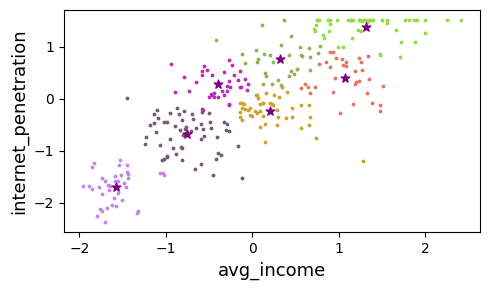

In [75]:
# just example checking how to use KMeans class to cluster the data and plot the various cluster centroids
cluster_no = 7
cluster    =  KMeans(n_clusters=cluster_no, random_state=42, max_iter=300)  
clustered_data    =    cluster.fit(std_two_coloums)
clustered_data_labels    =    clustered_data.labels_
clustered_data_centers   =    clustered_data.cluster_centers_
# appending a coloumn to the std_two_coloums called cluster_number that indicates which cluster the data belongs to
two_coloums["cluster_number"]    =    clustered_data.labels_
#print(two_coloums)
# plotting the scatter plot of the above standardized two coloums to see if any clusters are possible with the cluster centers
#color    =    ["red", "green", "blue", "orange", "black"]
color = np.random.rand(cluster_no, 3)  # RGB values
unique_labels    =    np.unique(clustered_data.labels_)
figsize=(5,3)
plt.figure(1, figsize=figsize)
#[plt.scatter(two_coloums[:,0,j], std_two_coloums[:,1,j],s=3,color=color[j]) for j in range(cluster_no)]
for label in unique_labels:
    unique_std_clustered_data    =    std_two_coloums[clustered_data_labels==label]
    plt.scatter(unique_std_clustered_data[:,0], unique_std_clustered_data[:,1],s=3, color=color[label])
plt.scatter(clustered_data_centers[:,0], clustered_data_centers[:,1],s=42, color="purple",marker="*")
plt.xlabel(c1, fontsize=13)
plt.ylabel(c2, fontsize=13)
plt.tight_layout()
plt.show()